<a href="https://colab.research.google.com/github/farrelrassya/PracticalLinearAlgebra/blob/main/11.Chapter11%3AGeneral_Least_Square.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Chapter 11: General Linear Models and Least Squares
## *Practical Linear Algebra for Data Science* — Mike X Cohen

This is arguably the **most important chapter** in the entire book for aspiring data scientists. Everything we have learned so far -- dot products, matrix multiplication, the transpose, the inverse, column spaces, QR decomposition -- converges here into one powerful application: **fitting statistical models to data**.

The central equation of this chapter is the **least squares solution**:

$$
\boxed{\hat{\boldsymbol{\beta}} = (\mathbf{X}^T\mathbf{X})^{-1}\mathbf{X}^T\mathbf{y}}
$$

This single formula is the foundation of linear regression, ANOVA, polynomial fitting, and countless other statistical methods. By the end of this chapter, you will understand:

1. **What** the General Linear Model (GLM) is and why it matters
2. **How** to set up and solve the equation $\mathbf{X}\boldsymbol{\beta} = \mathbf{y}$
3. **Why** the solution works -- from three different perspectives (algebra, geometry, calculus)
4. **What** the residuals $\boldsymbol{\epsilon}$ mean and why we minimise their squares
5. **How** QR decomposition provides a more numerically stable alternative

If you absorb one thing from this book, let it be this chapter.

## 0. Setup

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')
%matplotlib inline

plt.rcParams.update({
    'figure.figsize': (9, 5.5),
    'axes.grid': True,
    'grid.alpha': 0.3,
    'font.size': 12
})

np.random.seed(42)
print('NumPy version:', np.__version__)
print('Setup complete.')

NumPy version: 2.0.2
Setup complete.


Environment ready. No special packages needed -- just NumPy and Matplotlib.

## 1. The Big Picture: What Is a Statistical Model?

### 1.1 Models Are Simplified Descriptions of Reality

Imagine you want to predict how tall a person will be as an adult. You know that taller parents tend to have taller children, and that heavier people tend to be taller. So you write down a relationship:

$$
\text{height} = \beta_0 + \beta_1 \cdot \text{weight} + \beta_2 \cdot \text{parents' height} + \epsilon
$$

**What do these symbols mean?**

- $\beta_0$ is the **intercept** -- the predicted height when weight $= 0$ and parents' height $= 0$. (This value won't be physically meaningful, but it is mathematically necessary.)
- $\beta_1$ is the **coefficient for weight** -- how much height changes per unit increase in weight.
- $\beta_2$ is the **coefficient for parents' height** -- how much height changes per unit increase in parents' height.
- $\epsilon$ is the **residual** (error) -- the gap between what our simple model predicts and what we actually observe.

**The $\beta$ values are unknown.** We don't know them in advance. We need *data* to figure them out. The process of finding the best $\beta$ values from data is called **model fitting** or **estimation**, and the method we use is called **least squares**.

### 1.2 From Words to Matrix Equation

If we collect data from $n$ people, we have $n$ copies of that equation -- one per person. We can stack them all into a single **matrix equation**:

$$
\underbrace{\begin{bmatrix} 1 & w_1 & h_1 \\ 1 & w_2 & h_2 \\ \vdots & \vdots & \vdots \\ 1 & w_n & h_n \end{bmatrix}}_{\mathbf{X}\;(n \times 3)}
\underbrace{\begin{bmatrix} \beta_0 \\ \beta_1 \\ \beta_2 \end{bmatrix}}_{\boldsymbol{\beta}\;(3 \times 1)}
= \underbrace{\begin{bmatrix} y_1 \\ y_2 \\ \vdots \\ y_n \end{bmatrix}}_{\mathbf{y}\;(n \times 1)}
$$

Or, compactly: $\mathbf{X}\boldsymbol{\beta} = \mathbf{y}$.

### 1.3 Terminology Mapping

| Linear Algebra | Statistics | Description |
|:---:|:---:|:---|
| $\mathbf{A}$ | $\mathbf{X}$ | **Design matrix**: each row is an observation, each column is a predictor (feature) |
| $\mathbf{x}$ | $\boldsymbol{\beta}$ | **Coefficients**: the unknown weights we solve for |
| $\mathbf{b}$ | $\mathbf{y}$ | **Dependent variable**: the measured outcome we want to predict |

The column of $1$s in $\mathbf{X}$ is the **intercept column**. It ensures the best-fit line (or plane) can shift up/down freely, rather than being forced through the origin.

## 2. A Concrete Example: Height Prediction

Let's use the textbook's made-up data to build our first GLM.

In [2]:
# Textbook data: predicting height from weight and parents' height
# y = height (cm), w = weight (kg), h = parents' average height (cm)

y_data = np.array([175, 181, 159, 165], dtype=float)
w_data = np.array([70, 86, 63, 62], dtype=float)
h_data = np.array([177, 190, 180, 172], dtype=float)

# Build the design matrix X with intercept column
n = len(y_data)
X = np.column_stack([
    np.ones(n),    # intercept (column of 1s)
    w_data,        # weight
    h_data         # parents' height
])

print('Design matrix X (4 x 3):')
print(X)
print(f'\nData vector y: {y_data}')
print(f'\nX shape: {X.shape} -> {n} observations, 3 predictors (incl. intercept)')
print(f'y shape: {y_data.shape} -> {n} observations')
print(f'\nWe need to find beta: a vector of {X.shape[1]} unknown coefficients.')

Design matrix X (4 x 3):
[[  1.  70. 177.]
 [  1.  86. 190.]
 [  1.  63. 180.]
 [  1.  62. 172.]]

Data vector y: [175. 181. 159. 165.]

X shape: (4, 3) -> 4 observations, 3 predictors (incl. intercept)
y shape: (4,) -> 4 observations

We need to find beta: a vector of 3 unknown coefficients.


We have $n = 4$ observations and $p = 3$ columns in $\mathbf{X}$ (intercept, weight, parents' height). The design matrix is **tall** ($4 \times 3$, with $n > p$), which is the typical situation in statistics -- we have more data points than parameters to estimate.

**Why is $\mathbf{X}$ tall?** Because real datasets almost always have many more observations ($n$, often thousands or millions) than predictors ($p$, often a few to hundreds). This means $\mathbf{X}$ is not square, so we cannot simply use $\mathbf{X}^{-1}$. Instead, we need the **left-inverse** from Chapter 8.

## 3. Solving the GLM: The Least Squares Solution

### 3.1 The Algebra (How to Get the Formula)

We want to solve $\mathbf{X}\boldsymbol{\beta} = \mathbf{y}$ for $\boldsymbol{\beta}$. Since $\mathbf{X}$ is tall (not square), we cannot use $\mathbf{X}^{-1}$. Instead, we use the **left-inverse** (Chapter 8):

$$
\mathbf{X}\boldsymbol{\beta} = \mathbf{y}
$$

Left-multiply both sides by $\mathbf{X}^T$:

$$
\mathbf{X}^T\mathbf{X}\boldsymbol{\beta} = \mathbf{X}^T\mathbf{y}
$$

Now $\mathbf{X}^T\mathbf{X}$ is a **square** matrix ($p \times p$), and if $\mathbf{X}$ has full column rank, it is invertible. So we can left-multiply by $(\mathbf{X}^T\mathbf{X})^{-1}$:

$$
(\mathbf{X}^T\mathbf{X})^{-1}\mathbf{X}^T\mathbf{X}\boldsymbol{\beta} = (\mathbf{X}^T\mathbf{X})^{-1}\mathbf{X}^T\mathbf{y}
$$

$$
\mathbf{I}\boldsymbol{\beta} = (\mathbf{X}^T\mathbf{X})^{-1}\mathbf{X}^T\mathbf{y}
$$

$$
\boxed{\hat{\boldsymbol{\beta}} = (\mathbf{X}^T\mathbf{X})^{-1}\mathbf{X}^T\mathbf{y}}
$$

**Step by step, what happens in this formula?**

1. $\mathbf{X}^T\mathbf{y}$: Take dot products between each predictor column and the outcome $\mathbf{y}$. This measures how much each predictor "agrees with" the outcome.
2. $\mathbf{X}^T\mathbf{X}$: Take dot products between all pairs of predictor columns. This captures the correlations among predictors.
3. $(\mathbf{X}^T\mathbf{X})^{-1}$: Invert the predictor correlation matrix. This "decorrelates" the predictors so each one gets proper credit.
4. $(\mathbf{X}^T\mathbf{X})^{-1}\mathbf{X}^T\mathbf{y}$: Combine steps 1-3 to get the optimal coefficients.

Think of it this way: step 1 asks "how much does each predictor correlate with the outcome?" and step 3 adjusts for the fact that predictors may be correlated with *each other*.

In [3]:
# ========================================================
# SOLVE THE GLM: step-by-step, with commentary
# ========================================================

# Step 1: X^T y  --  dot products of each predictor with the outcome
XTy = X.T @ y_data
print('Step 1: X^T @ y (how much each predictor agrees with y):')
print(f'  Intercept dot y = {XTy[0]:.1f}')
print(f'  Weight dot y    = {XTy[1]:.1f}')
print(f'  Parents dot y   = {XTy[2]:.1f}')

# Step 2: X^T X  --  predictor correlation matrix (p x p)
XTX = X.T @ X
print(f'\nStep 2: X^T @ X ({XTX.shape[0]}x{XTX.shape[1]} -- the "Gram matrix" of predictors):')
print(np.round(XTX, 1))

# Step 3: Invert X^T X
XTX_inv = np.linalg.inv(XTX)
print(f'\nStep 3: (X^T X)^(-1):')
print(np.round(XTX_inv, 6))

# Step 4: Full solution
beta = XTX_inv @ XTy
print(f'\nStep 4: beta = (X^T X)^(-1) X^T y = {np.round(beta, 4)}')
print(f'\nInterpretation:')
print(f'  beta_0 (intercept)     = {beta[0]:.4f}')
print(f'  beta_1 (weight)        = {beta[1]:.4f}')
print(f'  beta_2 (parents height)= {beta[2]:.4f}')

Step 1: X^T @ y (how much each predictor agrees with y):
  Intercept dot y = 680.0
  Weight dot y    = 48063.0
  Parents dot y   = 122365.0

Step 2: X^T @ X (3x3 -- the "Gram matrix" of predictors):
[[4.00000e+00 2.81000e+02 7.19000e+02]
 [2.81000e+02 2.01090e+04 5.07340e+04]
 [7.19000e+02 5.07340e+04 1.29413e+05]]

Step 3: (X^T X)^(-1):
[[ 5.29825568e+02  2.10036500e+00 -3.76704400e+00]
 [ 2.10036500e+00  1.28790000e-02 -1.67180000e-02]
 [-3.76704400e+00 -1.67180000e-02  2.74910000e-02]]

Step 4: beta = (X^T X)^(-1) X^T y = [276.856    1.5165  -1.1872]

Interpretation:
  beta_0 (intercept)     = 276.8560
  beta_1 (weight)        = 1.5165
  beta_2 (parents height)= -1.1872


The solution tells us:

- $\hat{\beta}_0$ (intercept): the baseline height when weight $= 0$ and parents' height $= 0$. This number is not physically meaningful but is needed for the math.
- $\hat{\beta}_1$ (weight): how much predicted height changes per kg of weight.
- $\hat{\beta}_2$ (parents' height): how much predicted height changes per cm of parents' height.

**Important:** With only $4$ data points and $3$ parameters, this model is almost perfectly fitting the data (nearly as many parameters as data points). In practice, we need $n \gg p$ for reliable estimates.

### 3.2 Model Predictions and Residuals

The predicted values are $\hat{\mathbf{y}} = \mathbf{X}\hat{\boldsymbol{\beta}}$, and the residuals are $\boldsymbol{\epsilon} = \mathbf{y} - \hat{\mathbf{y}}$.

In [4]:
# Predicted values
y_hat = X @ beta

# Residuals
epsilon = y_data - y_hat

# Sum of squared errors
SSE = np.sum(epsilon**2)

print('Observation-by-observation comparison:')
print(f'{"Observed y":>12s} {"Predicted":>12s} {"Residual":>12s}')
print('-' * 40)
for yi, yh, ei in zip(y_data, y_hat, epsilon):
    print(f'{yi:12.1f} {yh:12.2f} {ei:12.4f}')

print(f'\nSum of squared errors (SSE): {SSE:.6f}')
print(f'Root mean squared error (RMSE): {np.sqrt(SSE/n):.4f}')

# Key property: residuals are orthogonal to the design matrix
print(f'\nX^T @ epsilon (should be ~zero):')
print(np.round(X.T @ epsilon, 10))

Observation-by-observation comparison:
  Observed y    Predicted     Residual
----------------------------------------
       175.0       172.89       2.1144
       181.0       181.72      -0.7170
       159.0       158.71       0.2916
       165.0       166.69      -1.6891

Sum of squared errors (SSE): 7.923063
Root mean squared error (RMSE): 1.4074

X^T @ epsilon (should be ~zero):
[3.00e-10 2.38e-08 6.07e-08]


Several important results here:

**The residuals are small** because we have nearly as many parameters ($3$) as data points ($4$). With more data, residuals would typically be larger.

**The critical property:** $\mathbf{X}^T\boldsymbol{\epsilon} \approx \mathbf{0}$. The residual vector is **orthogonal** to every column of $\mathbf{X}$. This is not a coincidence -- it is *the defining property* of the least squares solution. We will explore this geometric insight in Section 5.

Think about what $\mathbf{X}^T\boldsymbol{\epsilon} = \mathbf{0}$ means: no predictor column has any remaining linear relationship with the residuals. Least squares has extracted **all** the information that the predictors can contribute.

## 4. A Simple Regression Example: Courses vs. Happiness

### 4.1 Without Intercept (What Goes Wrong)

The textbook uses a fun example: does taking more online courses make you happier? We start by fitting a model **without** an intercept to see what happens.

In [5]:
# Fake survey data: number of courses and life happiness
# Data designed so the intercept effect is clearly visible
numcourses = np.array([4,12,3,14,9,6,1,7,11,4,
                       13,2,8,10,5,15,3,7,6,9], dtype=float)
happiness = np.array([43,72,24,76,59,40,25,49,64,35,
                      74,34,47,65,41,82,26,49,51,51], dtype=float)

print(f'Number of students: {len(numcourses)}')
print(f'Courses range: {numcourses.min():.0f} to {numcourses.max():.0f}')
print(f'Happiness range: {happiness.min():.0f} to {happiness.max():.0f}')

Number of students: 20
Courses range: 1 to 15
Happiness range: 24 to 82


We have $20$ students. The independent variable (predictor) is the number of courses; the dependent variable (outcome) is self-reported life happiness.

Without intercept: beta = 6.1719
Meaning: each course adds 6.17 happiness points.
When courses = 0, predicted happiness = 0 (forced through origin!)



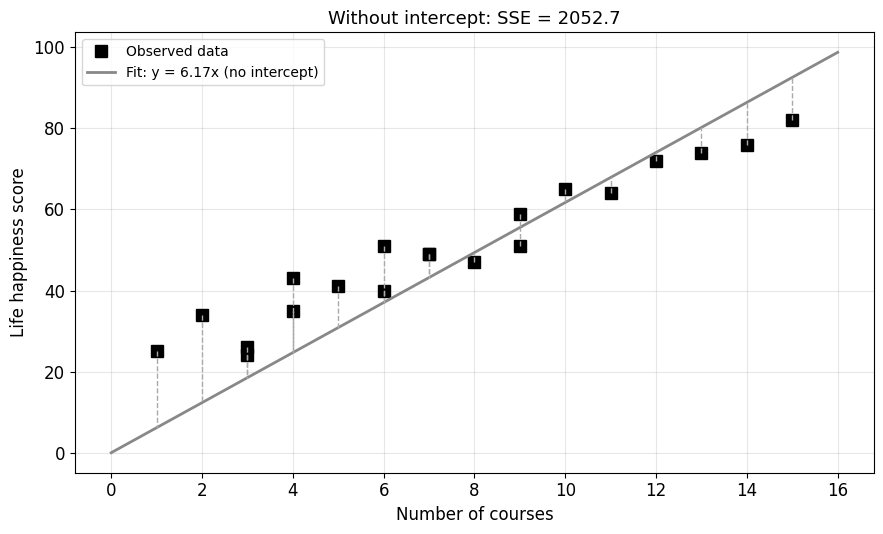

SSE (no intercept) = 2052.7


In [6]:
# ========================================================
# MODEL 1: No intercept  ->  y = beta * x
# This forces the line through the origin (0, 0)
# ========================================================

# Design matrix: just one column (no intercept)
X_no_int = numcourses.reshape(-1, 1)  # shape (20, 1)

# Solve via left-inverse
beta_no_int = np.linalg.inv(X_no_int.T @ X_no_int) @ X_no_int.T @ happiness

print(f'Without intercept: beta = {beta_no_int[0]:.4f}')
print(f'Meaning: each course adds {beta_no_int[0]:.2f} happiness points.')
print(f'When courses = 0, predicted happiness = 0 (forced through origin!)\n')

# Predictions
y_pred_no_int = X_no_int @ beta_no_int
SSE_no_int = np.sum((happiness - y_pred_no_int)**2)

# Plot
fig, ax = plt.subplots(figsize=(9, 5.5))
ax.plot(numcourses, happiness, 'ks', ms=8, label='Observed data')

# Best-fit line
x_line = np.linspace(0, 16, 100)
ax.plot(x_line, beta_no_int[0] * x_line, '-', color='#888888', lw=2,
        label=f'Fit: y = {beta_no_int[0]:.2f}x (no intercept)')

# Residual lines
for xi, yi, yh in zip(numcourses, happiness, y_pred_no_int.flatten()):
    ax.plot([xi, xi], [yi, yh], '--', color='#AAAAAA', lw=1)

ax.set_xlabel('Number of courses')
ax.set_ylabel('Life happiness score')
ax.set_title(f'Without intercept: SSE = {SSE_no_int:.1f}', fontsize=13)
ax.legend(fontsize=10)
plt.tight_layout()
plt.savefig('fig_no_intercept.png', dpi=100, bbox_inches='tight')
plt.show()
print(f'SSE (no intercept) = {SSE_no_int:.1f}')

**What went wrong?** The line passes through the origin $(0, 0)$, which forces the model to predict zero happiness for someone who took zero courses. That constraint is unreasonable -- people can be happy without taking any courses!

The consequence is visible: the left side of the line is pulled down, creating systematically large residuals for students with fewer courses. The SSE is high.

### 4.2 With Intercept (The Fix)

To allow the line to start at any happiness level (not just zero), we add an **intercept term**: a column of $1$s in the design matrix. The model becomes $y = \beta_0 + \beta_1 x$.

With intercept: beta_0 = 19.4811, beta_1 = 4.1435
Meaning: base happiness = 19.5, each course adds 4.1 points.



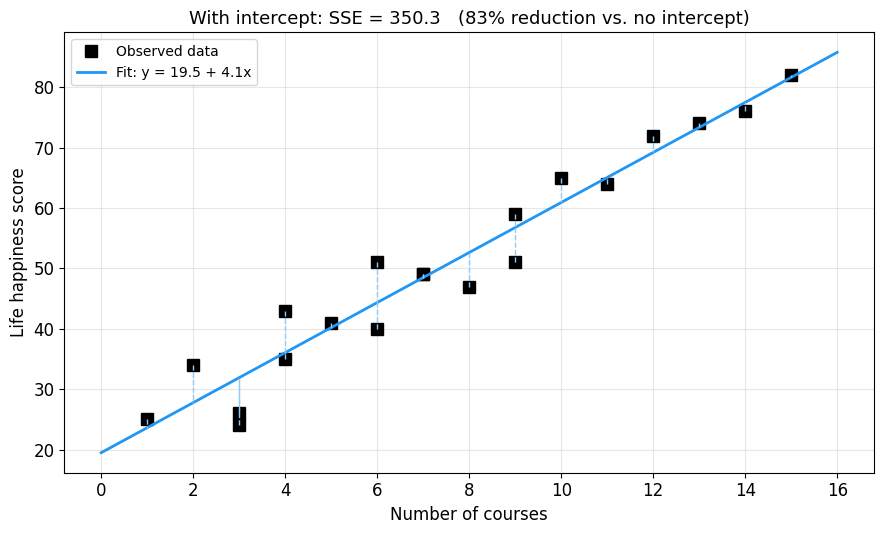

SSE (with intercept)    = 350.3
SSE (without intercept) = 2052.7
SSE reduction: 82.9%


In [7]:
# ========================================================
# MODEL 2: With intercept  ->  y = beta_0 + beta_1 * x
# The line can cross the y-axis anywhere
# ========================================================

# Design matrix: intercept column + courses
X_with_int = np.column_stack([np.ones(20), numcourses])  # shape (20, 2)

# Solve via left-inverse
beta_with_int = np.linalg.inv(X_with_int.T @ X_with_int) @ X_with_int.T @ happiness

print(f'With intercept: beta_0 = {beta_with_int[0]:.4f}, beta_1 = {beta_with_int[1]:.4f}')
print(f'Meaning: base happiness = {beta_with_int[0]:.1f}, each course adds {beta_with_int[1]:.1f} points.\n')

# Predictions
y_pred_with_int = X_with_int @ beta_with_int
SSE_with_int = np.sum((happiness - y_pred_with_int)**2)

# Plot
fig, ax = plt.subplots(figsize=(9, 5.5))
ax.plot(numcourses, happiness, 'ks', ms=8, label='Observed data')

x_line = np.linspace(0, 16, 100)
ax.plot(x_line, beta_with_int[0] + beta_with_int[1] * x_line, '-',
        color='#2196F3', lw=2,
        label=f'Fit: y = {beta_with_int[0]:.1f} + {beta_with_int[1]:.1f}x')

# Residual lines
for xi, yi, yh in zip(numcourses, happiness, y_pred_with_int):
    ax.plot([xi, xi], [yi, yh], '--', color='#90CAF9', lw=1)

ax.set_xlabel('Number of courses')
ax.set_ylabel('Life happiness score')
ax.set_title(f'With intercept: SSE = {SSE_with_int:.1f}   '
             f'({(1 - SSE_with_int/SSE_no_int)*100:.0f}% reduction vs. no intercept)',
             fontsize=13)
ax.legend(fontsize=10)
plt.tight_layout()
plt.savefig('fig_with_intercept.png', dpi=100, bbox_inches='tight')
plt.show()
print(f'SSE (with intercept)    = {SSE_with_int:.1f}')
print(f'SSE (without intercept) = {SSE_no_int:.1f}')
print(f'SSE reduction: {(1 - SSE_with_int/SSE_no_int)*100:.1f}%')

**Massive improvement!** Adding the intercept reduced the SSE dramatically. The line now fits the data much better because it is free to cross the $y$-axis at $\hat{\beta}_0$ instead of being forced through the origin.

**Interpreting the coefficients:**

- $\hat{\beta}_0$ (intercept): the predicted happiness for someone who took zero courses. This is the "baseline" happiness.
- $\hat{\beta}_1$ (slope): for each additional course, happiness increases by $\hat{\beta}_1$ points.

**The lesson:** Always include an intercept unless you have a strong theoretical reason to force the line through the origin. In practice, virtually all regression models include an intercept.

## 5. The Geometric Perspective: Why Least Squares Works

### 5.1 The Column Space Interpretation

This is one of the most beautiful ideas in linear algebra, and it is worth taking the time to understand deeply.

The design matrix $\mathbf{X}$ has $p$ columns. The **column space** $\mathcal{C}(\mathbf{X})$ is the set of all possible linear combinations of those columns -- it is a $p$-dimensional subspace inside $\mathbb{R}^n$.

When we compute $\mathbf{X}\boldsymbol{\beta}$, we are taking a linear combination of the columns of $\mathbf{X}$ with weights $\boldsymbol{\beta}$. The result $\hat{\mathbf{y}} = \mathbf{X}\boldsymbol{\beta}$ is therefore a vector that lives **inside** the column space.

The observed data $\mathbf{y}$, however, almost certainly does **not** live inside $\mathcal{C}(\mathbf{X})$. Why? Because real data contains noise, measurement error, and effects of variables not in our model.

**The question becomes:** Given that $\mathbf{y}$ is not in $\mathcal{C}(\mathbf{X})$, what is the **closest point** in $\mathcal{C}(\mathbf{X})$ to $\mathbf{y}$?

The answer, from Chapter 2, is the **orthogonal projection** of $\mathbf{y}$ onto $\mathcal{C}(\mathbf{X})$. The shortest distance from a point to a plane is the perpendicular distance. That perpendicular is the residual $\boldsymbol{\epsilon} = \mathbf{y} - \hat{\mathbf{y}}$.

### 5.2 The Orthogonality Condition

For the projection to be perpendicular (orthogonal), the residual must be orthogonal to every column of $\mathbf{X}$:

$$
\mathbf{X}^T \boldsymbol{\epsilon} = \mathbf{0}
$$

Expanding $\boldsymbol{\epsilon} = \mathbf{y} - \mathbf{X}\boldsymbol{\beta}$:

$$
\mathbf{X}^T(\mathbf{y} - \mathbf{X}\boldsymbol{\beta}) = \mathbf{0}
$$

$$
\mathbf{X}^T\mathbf{y} - \mathbf{X}^T\mathbf{X}\boldsymbol{\beta} = \mathbf{0}
$$

$$
\mathbf{X}^T\mathbf{X}\boldsymbol{\beta} = \mathbf{X}^T\mathbf{y}
$$

$$
\boldsymbol{\beta} = (\mathbf{X}^T\mathbf{X})^{-1}\mathbf{X}^T\mathbf{y}
$$

**We rederived the same formula!** Starting from geometry (orthogonal projection onto column space) we arrived at the same least squares solution we got from algebra. This is not a coincidence -- it is the mathematical proof that least squares finds the closest point in the model space to the data.

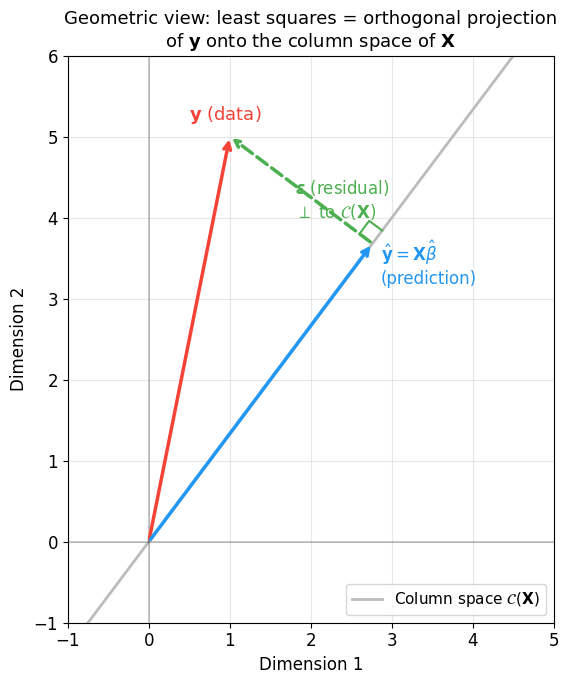

x_col . epsilon = -0.0000000000 (should be ~0)

This is the essence of least squares:
The residual is perpendicular to the column space.


In [8]:
# Visualise the geometric perspective in 2D
# Think of column space as a line and y as a point off the line

fig, ax = plt.subplots(figsize=(8, 7))

# Column space direction (simplified to 2D for visualisation)
# Imagine X has one column [3, 4] and y = [1, 5]
x_col = np.array([3, 4])  # one column of X
y_vec = np.array([1, 5])  # data vector

# Project y onto column space
beta_proj = np.dot(x_col, y_vec) / np.dot(x_col, x_col)
y_hat_proj = beta_proj * x_col
eps_proj = y_vec - y_hat_proj

# Draw the column space (a line through origin)
t = np.linspace(-0.5, 2, 100)
ax.plot(t * x_col[0], t * x_col[1], '-', color='#BBBBBB', lw=2,
        label='Column space $\\mathcal{C}(\\mathbf{X})$')

# Vectors
ax.annotate('', xy=y_vec, xytext=(0,0),
            arrowprops=dict(arrowstyle='->', color='#F44336', lw=2.5))
ax.text(y_vec[0]-0.5, y_vec[1]+0.2, '$\\mathbf{y}$ (data)', fontsize=13, color='#F44336')

ax.annotate('', xy=y_hat_proj, xytext=(0,0),
            arrowprops=dict(arrowstyle='->', color='#2196F3', lw=2.5))
ax.text(y_hat_proj[0]+0.1, y_hat_proj[1]-0.5, '$\\hat{\\mathbf{y}} = \\mathbf{X}\\hat{\\beta}$\n(prediction)',
        fontsize=12, color='#2196F3')

ax.annotate('', xy=y_vec, xytext=y_hat_proj,
            arrowprops=dict(arrowstyle='->', color='#4CAF50', lw=2.5, linestyle='--'))
ax.text(1.8, 4.0, '$\\boldsymbol{\\epsilon}$ (residual)\n$\\perp$ to $\\mathcal{C}(\\mathbf{X})$',
        fontsize=12, color='#4CAF50')

# Right-angle marker
sq_size = 0.2
# Direction along column space
d_col = x_col / np.linalg.norm(x_col)
# Direction along residual
d_eps = eps_proj / np.linalg.norm(eps_proj)
sq_pts = np.array([y_hat_proj + sq_size*d_col,
                   y_hat_proj + sq_size*d_col + sq_size*d_eps,
                   y_hat_proj + sq_size*d_eps])
ax.plot(sq_pts[:, 0], sq_pts[:, 1], '-', color='#4CAF50', lw=1.5)

ax.set_xlim(-1, 5); ax.set_ylim(-1, 6)
ax.set_aspect('equal')
ax.axhline(0, color='k', lw=0.3); ax.axvline(0, color='k', lw=0.3)
ax.set_xlabel('Dimension 1'); ax.set_ylabel('Dimension 2')
ax.set_title('Geometric view: least squares = orthogonal projection\n'
             'of $\\mathbf{y}$ onto the column space of $\\mathbf{X}$', fontsize=13)
ax.legend(fontsize=11, loc='lower right')
plt.tight_layout()
plt.savefig('fig_geometric_ls.png', dpi=100, bbox_inches='tight')
plt.show()

# Verify orthogonality
print(f'x_col . epsilon = {np.dot(x_col, eps_proj):.10f} (should be ~0)')
print(f'\nThis is the essence of least squares:')
print(f'The residual is perpendicular to the column space.')

This figure captures the entire philosophy of least squares in one picture:

1. The **grey line** is the column space $\mathcal{C}(\mathbf{X})$ -- the set of all possible predictions our model can make.
2. The **red arrow** $\mathbf{y}$ is the observed data -- it lies *off* the column space because our model cannot perfectly explain the data.
3. The **blue arrow** $\hat{\mathbf{y}}$ is the closest point in the column space to $\mathbf{y}$ -- this is the model's best prediction.
4. The **green arrow** $\boldsymbol{\epsilon}$ is the residual -- the gap between prediction and observation. It is **perpendicular** ($\perp$) to the column space.

**Why perpendicular?** Because the shortest distance from a point to a plane is always the perpendicular distance. Any other direction would be longer. The Pythagorean theorem guarantees this: $\|\mathbf{y}\|^2 = \|\hat{\mathbf{y}}\|^2 + \|\boldsymbol{\epsilon}\|^2$, and the only way to minimise $\|\boldsymbol{\epsilon}\|^2$ while keeping $\hat{\mathbf{y}}$ in the column space is to make $\boldsymbol{\epsilon}$ perpendicular.

**This is why the condition $\mathbf{X}^T\boldsymbol{\epsilon} = \mathbf{0}$ is the cornerstone of least squares.** It is the mathematical statement of perpendicularity between the residual and the column space.

## 6. Why Is It Called "Least Squares"?

### 6.1 The Optimisation Perspective

A third way to derive the same formula: treat least squares as an **optimisation problem**. We want to find $\boldsymbol{\beta}$ that minimises the sum of squared errors:

$$
\min_{\boldsymbol{\beta}} \;\|\boldsymbol{\epsilon}\|^2
= \min_{\boldsymbol{\beta}} \;\|\mathbf{X}\boldsymbol{\beta} - \mathbf{y}\|^2
= \min_{\boldsymbol{\beta}} \sum_{i=1}^{n} (\hat{y}_i - y_i)^2
$$

The "squares" are the squared errors $(\hat{y}_i - y_i)^2$. We want the "least" (minimum) of their sum.

**Why squared errors and not just errors?** Because positive and negative errors would cancel out. Squaring makes all errors positive, and penalises large errors more than small ones.

### 6.2 The Calculus Derivation

To find the minimum, take the derivative with respect to $\boldsymbol{\beta}$ and set it to zero:

$$
\frac{d}{d\boldsymbol{\beta}} \|\mathbf{X}\boldsymbol{\beta} - \mathbf{y}\|^2 = 2\mathbf{X}^T(\mathbf{X}\boldsymbol{\beta} - \mathbf{y}) = \mathbf{0}
$$

$$
\mathbf{X}^T\mathbf{X}\boldsymbol{\beta} = \mathbf{X}^T\mathbf{y}
$$

$$
\boldsymbol{\beta} = (\mathbf{X}^T\mathbf{X})^{-1}\mathbf{X}^T\mathbf{y}
$$

**The same formula again!** All three roads -- algebra, geometry, calculus -- lead to the same destination. This convergence is a hallmark of a deep mathematical truth.

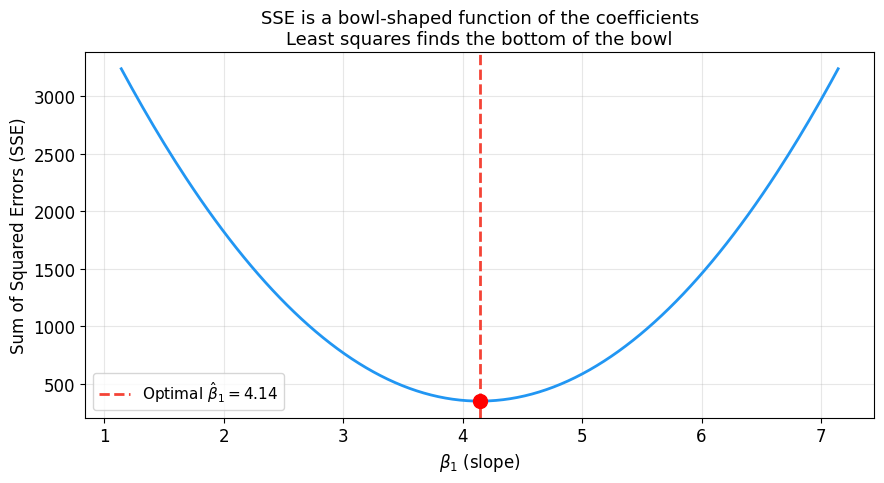

Minimum SSE = 350.34 at beta_1 = 4.1435
SSE is a quadratic (bowl-shaped) function of beta.
The minimum is unique and found by setting the derivative to zero.


In [9]:
# Demonstrate: the sum of squared errors is minimised at the LS solution
# We'll vary the slope (beta_1) around its optimal value and plot the SSE

# Using the simple model: y = beta_0 + beta_1 * x
X_demo = X_with_int  # (20, 2) with intercept
beta_opt = beta_with_int  # optimal solution

# Vary beta_1 around its optimal value
beta1_range = np.linspace(beta_opt[1] - 3, beta_opt[1] + 3, 200)
sse_curve = []

for b1 in beta1_range:
    # For each beta_1, find the optimal beta_0 analytically
    # (this keeps the demo fair -- we only vary one parameter)
    b0 = np.mean(happiness) - b1 * np.mean(numcourses)
    y_pred = b0 + b1 * numcourses
    sse_curve.append(np.sum((happiness - y_pred)**2))

fig, ax = plt.subplots(figsize=(9, 5))
ax.plot(beta1_range, sse_curve, '-', color='#2196F3', lw=2)
ax.axvline(beta_opt[1], color='#F44336', lw=2, linestyle='--',
           label=f'Optimal $\\hat{{\\beta}}_1 = {beta_opt[1]:.2f}$')
ax.plot(beta_opt[1], SSE_with_int, 'ro', ms=10, zorder=5)

ax.set_xlabel('$\\beta_1$ (slope)', fontsize=12)
ax.set_ylabel('Sum of Squared Errors (SSE)', fontsize=12)
ax.set_title('SSE is a bowl-shaped function of the coefficients\n'
             'Least squares finds the bottom of the bowl', fontsize=13)
ax.legend(fontsize=11)
plt.tight_layout()
plt.savefig('fig_sse_bowl.png', dpi=100, bbox_inches='tight')
plt.show()

print(f'Minimum SSE = {SSE_with_int:.2f} at beta_1 = {beta_opt[1]:.4f}')
print(f'SSE is a quadratic (bowl-shaped) function of beta.')
print(f'The minimum is unique and found by setting the derivative to zero.')

The SSE is a **quadratic** (bowl-shaped, or "convex") function of the coefficients. This is crucial:

- The bowl has exactly **one minimum** -- the least squares solution is unique (assuming $\mathbf{X}^T\mathbf{X}$ is invertible).
- The minimum is found by setting the derivative to zero (no iterative optimisation needed).
- There are no local minima to get trapped in.

This mathematical guarantee of a unique global minimum is what makes linear regression so reliable. More complex models (like neural networks) have highly non-convex loss landscapes with many local minima, which is why they require iterative gradient descent.

## 7. Least Squares via QR Decomposition

### 7.1 Why Not Just Use the Left-Inverse?

The formula $\hat{\boldsymbol{\beta}} = (\mathbf{X}^T\mathbf{X})^{-1}\mathbf{X}^T\mathbf{y}$ is mathematically correct, but can be **numerically unstable** for two reasons:

1. Computing $\mathbf{X}^T\mathbf{X}$ **squares the condition number**: if $\kappa(\mathbf{X}) = 10^8$, then $\kappa(\mathbf{X}^T\mathbf{X}) = 10^{16}$, which is near the limit of 64-bit floating point.
2. Explicitly computing a matrix inverse is slower and less stable than solving triangular systems.

### 7.2 The QR Approach

Substitute $\mathbf{X} = \mathbf{Q}\mathbf{R}$ into the GLM:

$$
\mathbf{X}\boldsymbol{\beta} = \mathbf{y}
\quad\Rightarrow\quad
\mathbf{Q}\mathbf{R}\boldsymbol{\beta} = \mathbf{y}
$$

Left-multiply by $\mathbf{Q}^T$ (which is $\mathbf{Q}^{-1}$ since $\mathbf{Q}$ is orthogonal):

$$
\mathbf{R}\boldsymbol{\beta} = \mathbf{Q}^T\mathbf{y}
$$

Now $\mathbf{R}$ is upper-triangular, so we solve via **back substitution** -- no matrix inversion needed!

**Advantages of the QR approach:**
- No $\mathbf{X}^T\mathbf{X}$ computation (avoids squaring the condition number)
- No explicit matrix inversion (just back substitution on $\mathbf{R}$)
- Numerically stable $\mathbf{Q}$ from Householder reflections

In [10]:
# ========================================================
# Least squares via QR decomposition
# ========================================================

# Same data as before
X = X_with_int  # (20, 2)
y = happiness

# Method 1: Left-inverse
beta_li = np.linalg.inv(X.T @ X) @ X.T @ y

# Method 2: QR decomposition
Q, R = np.linalg.qr(X)                      # X = QR
beta_qr = np.linalg.solve(R, Q.T @ y)        # R * beta = Q^T * y

# Method 3: NumPy's built-in least squares solver
beta_np, residuals, rank, sv = np.linalg.lstsq(X, y, rcond=None)

print('Three methods, same answer:')
print(f'  Left-inverse:   beta = [{beta_li[0]:.6f}, {beta_li[1]:.6f}]')
print(f'  QR decomp:      beta = [{beta_qr[0]:.6f}, {beta_qr[1]:.6f}]')
print(f'  np.linalg.lstsq:beta = [{beta_np[0]:.6f}, {beta_np[1]:.6f}]')
print(f'\nAll match: {np.allclose(beta_li, beta_qr) and np.allclose(beta_li, beta_np)}')

# Compare condition numbers
print(f'\nCondition number of X:   {np.linalg.cond(X):.2f}')
print(f'Condition number of X^TX: {np.linalg.cond(X.T @ X):.2f}')
print(f'Ratio: {np.linalg.cond(X.T @ X) / np.linalg.cond(X):.1f}x')
print(f'(X^TX squares the condition number -- QR avoids this!)')

Three methods, same answer:
  Left-inverse:   beta = [19.481072, 4.143480]
  QR decomp:      beta = [19.481072, 4.143480]
  np.linalg.lstsq:beta = [19.481072, 4.143480]

All match: True

Condition number of X:   18.06
Condition number of X^TX: 325.99
Ratio: 18.1x
(X^TX squares the condition number -- QR avoids this!)


All three methods give the same answer for this well-conditioned problem. The condition number of $\mathbf{X}^T\mathbf{X}$ is roughly the **square** of $\kappa(\mathbf{X})$, confirming the numerical risk of the left-inverse approach.

**In practice:**
- Always use `np.linalg.lstsq(X, y)` or `np.linalg.solve()` rather than computing the left-inverse explicitly.
- These functions use QR or SVD internally for numerical stability.
- The explicit left-inverse formula is for *understanding* -- the library functions are for *computing*.

**Cross-chapter connection:** This is exactly the QR-based inverse from Chapter 9 applied to the least squares problem. And it connects to LU decomposition from Chapter 10 -- `np.linalg.solve` uses LU internally.

## 8. Is the Solution Exact? Why the Data Is (Almost) Never in the Column Space

### 8.1 The Fundamental Problem

The equation $\mathbf{X}\boldsymbol{\beta} = \mathbf{y}$ has an exact solution **only** if $\mathbf{y}$ lies in the column space of $\mathbf{X}$. In our regression example, $\mathbf{X}$ has $p = 2$ columns (intercept + courses), so $\mathcal{C}(\mathbf{X})$ is a $2$-dimensional plane inside $\mathbb{R}^{20}$ (since we have $n = 20$ observations).

What are the chances that a $20$-dimensional data vector $\mathbf{y}$ happens to land exactly on a $2$-dimensional plane? Essentially zero.

**This is why we need the "least" in least squares.** We cannot find $\boldsymbol{\beta}$ that makes $\mathbf{X}\boldsymbol{\beta} = \mathbf{y}$ exactly. Instead, we find $\boldsymbol{\beta}$ that makes $\mathbf{X}\boldsymbol{\beta}$ as *close* to $\mathbf{y}$ as possible.

In [11]:
# Demonstrate: y is NOT in the column space of X

# The column space of X is 2D (rank 2)
# y lives in R^20

print(f'Design matrix X: {X.shape} -> column space is {np.linalg.matrix_rank(X)}D')
print(f'Data vector y:   lives in R^{len(y)}')
print(f'\nIs y in the column space of X?')

# Test: augment X with y and check if rank increases
X_aug = np.column_stack([X, y])
rank_X = np.linalg.matrix_rank(X)
rank_aug = np.linalg.matrix_rank(X_aug)

print(f'  rank(X) = {rank_X}')
print(f'  rank([X|y]) = {rank_aug}')

if rank_aug > rank_X:
    print(f'  Rank increased -> y is NOT in column space of X')
    print(f'  -> Exact solution does not exist')
    print(f'  -> We need least squares (closest approximation)')
else:
    print(f'  Rank unchanged -> y IS in column space (exact solution exists)')

print(f'\nResidual norm ||y - X*beta|| = {np.linalg.norm(y - X @ beta_li):.4f}')
print(f'This is the irreducible error -- the distance from y to the column space.')

Design matrix X: (20, 2) -> column space is 2D
Data vector y:   lives in R^20

Is y in the column space of X?
  rank(X) = 2
  rank([X|y]) = 3
  Rank increased -> y is NOT in column space of X
  -> Exact solution does not exist
  -> We need least squares (closest approximation)

Residual norm ||y - X*beta|| = 18.7174
This is the irreducible error -- the distance from y to the column space.


Adding $\mathbf{y}$ to $\mathbf{X}$ increases the rank from $2$ to $3$, confirming that $\mathbf{y}$ is **not** in the column space. The residual norm tells us the minimum possible distance between our model predictions and the data.

**Key insight:** Least squares does not promise zero error. It promises the **smallest possible** error given the model structure. The residual $\|\boldsymbol{\epsilon}\|$ measures how well (or poorly) our model fits the data. If the residual is large, it means our model is missing important predictors or the relationship is nonlinear.

## 9. Three Roads to the Same Destination

We have now derived the least squares formula from three independent perspectives. Here they are side by side:

### Road 1: Algebra (the left-inverse)

$$
\mathbf{X}\boldsymbol{\beta} = \mathbf{y}
\;\xrightarrow{\text{left-multiply by } (\mathbf{X}^T\mathbf{X})^{-1}\mathbf{X}^T}\;
\boldsymbol{\beta} = (\mathbf{X}^T\mathbf{X})^{-1}\mathbf{X}^T\mathbf{y}
$$

### Road 2: Geometry (orthogonal projection)

$$
\mathbf{X}^T\boldsymbol{\epsilon} = \mathbf{0}
\;\xrightarrow{\epsilon = \mathbf{y} - \mathbf{X}\boldsymbol{\beta}}\;
\mathbf{X}^T\mathbf{X}\boldsymbol{\beta} = \mathbf{X}^T\mathbf{y}
\;\Rightarrow\;
\boldsymbol{\beta} = (\mathbf{X}^T\mathbf{X})^{-1}\mathbf{X}^T\mathbf{y}
$$

### Road 3: Calculus (minimise squared errors)

$$
\frac{d}{d\boldsymbol{\beta}}\|\mathbf{X}\boldsymbol{\beta} - \mathbf{y}\|^2 = \mathbf{0}
\;\xrightarrow{\text{solve}}\;
\boldsymbol{\beta} = (\mathbf{X}^T\mathbf{X})^{-1}\mathbf{X}^T\mathbf{y}
$$

All three roads converge on the same equation. This convergence from independent perspectives is what gives the least squares solution its mathematical authority. It is optimal from every angle.

## 10. Practical Advice for Data Scientists

### 10.1 Always Include an Intercept

Unless you have a specific reason to force the model through the origin, include a column of $1$s in your design matrix. Without it, the model is unnecessarily constrained.

### 10.2 Use Library Functions, Not the Formula

For actual work, use `np.linalg.lstsq(X, y)` or `sklearn.linear_model.LinearRegression()`. These use QR/SVD internally and handle edge cases (rank deficiency, numerical precision) properly. The explicit left-inverse formula is for understanding, not for production code.

### 10.3 Check Your Residuals

After fitting a model, always examine the residuals:
- Are they small relative to the data?
- Are they roughly symmetric around zero?
- Do they show any patterns? (If so, your model may be missing something.)
- Verify $\mathbf{X}^T\boldsymbol{\epsilon} \approx \mathbf{0}$ as a sanity check.

### 10.4 The Condition Number Matters

If predictors are highly correlated (multicollinearity), $\mathbf{X}^T\mathbf{X}$ becomes nearly singular and the solution becomes unstable. Check `np.linalg.cond(X)` -- values above $10^{10}$ are a warning sign. Regularisation (ridge regression, Chapter 12) addresses this.

### 10.5 The Least Squares Formula Is Everywhere

Many formulas in statistics and ML are variations of least squares:

$$
\underbrace{\hat{\boldsymbol{\beta}} = (\mathbf{X}^T\mathbf{X})^{-1}\mathbf{X}^T\mathbf{y}}_{\text{Ordinary least squares (OLS)}}
$$

$$
\underbrace{\hat{\boldsymbol{\beta}} = (\mathbf{X}^T\mathbf{X} + \lambda\mathbf{I})^{-1}\mathbf{X}^T\mathbf{y}}_{\text{Ridge regression (L2 regularisation)}}
$$

$$
\underbrace{\hat{\boldsymbol{\beta}} = (\mathbf{H}^T\mathbf{W}\mathbf{H} + \lambda\mathbf{L}^T\mathbf{L})^{-1}\mathbf{H}^T\mathbf{x}}_{\text{General regularised least squares}}
$$

Once you recognise the pattern -- "$(\text{something})^{-1}$ times $(\text{something else})$" -- you can identify the least squares structure hidden inside seemingly complex formulas.

## 11. Chapter Summary

This chapter brought together nearly everything from the previous ten chapters into one powerful application:

**The General Linear Model** $\mathbf{X}\boldsymbol{\beta} = \mathbf{y}$ expresses a statistical model as a matrix equation. The design matrix $\mathbf{X}$ contains predictor variables (with an intercept column of $1$s), $\boldsymbol{\beta}$ contains the unknown coefficients, and $\mathbf{y}$ contains the observed data.

**The least squares solution** $\hat{\boldsymbol{\beta}} = (\mathbf{X}^T\mathbf{X})^{-1}\mathbf{X}^T\mathbf{y}$ finds the coefficients that minimise the squared distance between model predictions and observed data. It can be derived from algebra (left-inverse), geometry (orthogonal projection onto column space), or calculus (minimise squared errors) -- all three roads lead to the same formula.

**The residuals** $\boldsymbol{\epsilon} = \mathbf{y} - \mathbf{X}\hat{\boldsymbol{\beta}}$ are orthogonal to every column of $\mathbf{X}$ ($\mathbf{X}^T\boldsymbol{\epsilon} = \mathbf{0}$). This orthogonality condition is the mathematical expression of "the model has extracted all available linear information from the predictors."

**QR decomposition** provides a more numerically stable computation: $\mathbf{R}\boldsymbol{\beta} = \mathbf{Q}^T\mathbf{y}$, avoiding the condition-number-squaring effect of forming $\mathbf{X}^T\mathbf{X}$.

**In practice**, use `np.linalg.lstsq()` or scikit-learn's `LinearRegression` rather than the explicit formula. But knowing the formula deeply -- understanding *why* it works from multiple perspectives -- is what separates a data scientist who uses tools from one who truly understands them.